In [1]:
def main(datasources, start_date, end_date):
    """
    财报冲击下的日内市场信息遗漏因子

    核心逻辑：
    1. 使用最新可见MRQ财务数据计算盈利同比冲击；
    2. 使用营业收入同比变化确认盈利冲击；
    3. 财务报告越新，财务条件权重越高；
    4. 使用中证1000分钟收益中位数代表市场分钟收益；
    5. 估计股票当日对市场收益的Beta和日内同步性；
    6. 市场信息遗漏 = Beta × 市场收益 - 股票实际收益；
    7. 财报冲击越极端、越新、日内同步性越低，
       市场信息遗漏信号的权重越大。

    正值：
        股票相对市场少涨或多跌，存在潜在补涨信息。

    负值：
        股票相对市场少跌或多涨，存在潜在补跌信息。

    注意：
    - 财务数据只向后匹配，不使用未来公告；
    - 分钟市场收益仅使用中证1000历史成分股计算；
    - 最终输出仅包含date、instrument、factor。
    """

    import dai
    import numpy as np
    import pandas as pd

    # ========================================================
    # 1. 数据源检查
    # ========================================================
    required_sources = {
        "bar1m",
        "financial"
    }

    missing_sources = (
        required_sources
        - set(datasources.keys())
    )

    if missing_sources:
        raise KeyError(
            f"datasources缺少数据源：{sorted(missing_sources)}"
        )

    bar1m_table = datasources["bar1m"]
    financial_table = datasources["financial"]

    # ========================================================
    # 2. 日期设置
    # ========================================================
    target_start = pd.to_datetime(
        start_date,
        errors="raise"
    ).normalize()

    target_end = pd.to_datetime(
        end_date,
        errors="raise"
    ).normalize()

    if target_end < target_start:
        raise ValueError("end_date不能早于start_date")

    query_start = target_start.strftime(
        "%Y-%m-%d 00:00:00"
    )

    query_end = (
        target_end
        + pd.Timedelta(days=1)
        - pd.Timedelta(seconds=1)
    ).strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    permitted_start = pd.Timestamp("2019-01-01")

    financial_history_start = max(
        target_start - pd.Timedelta(days=550),
        permitted_start
    )

    financial_query_start = (
        financial_history_start.strftime(
            "%Y-%m-%d 00:00:00"
        )
    )

    # ========================================================
    # 3. 构造日内市场信息遗漏
    #
    # 每一分钟：
    # 市场收益 = 中证1000成分股分钟收益中位数
    #
    # 每只股票每日：
    # beta = Cov(stock, market) / Var(market)
    # sync = Corr(stock, market)
    # neglect = beta × market_return - stock_return
    # ========================================================
    high_frequency_sql = f"""
    WITH universe_quotes AS (
        SELECT
            b.date,
            b.instrument,
            b.date::DATE AS trading_day,

            CASE
                WHEN EXTRACT(HOUR FROM b.date) < 12
                    THEN 1
                ELSE 2
            END AS trading_session,

            (
                CAST(b.bid_price1 AS DOUBLE)
                +
                CAST(b.ask_price1 AS DOUBLE)
            ) / 2.0 AS mid_price

        FROM {bar1m_table} AS b

        INNER JOIN bigalpha_2026_instruments AS u
            ON b.date::DATE = u.date::DATE
            AND b.instrument = u.instrument

        WHERE
            b.bid_price1 IS NOT NULL
            AND b.ask_price1 IS NOT NULL
            AND b.bid_price1 > 0
            AND b.ask_price1 > 0
            AND b.ask_price1 >= b.bid_price1
    ),

    with_previous AS (
        SELECT
            date,
            instrument,
            trading_day,
            trading_session,
            mid_price,

            LAG(mid_price) OVER (
                PARTITION BY
                    trading_day,
                    instrument,
                    trading_session
                ORDER BY date
            ) AS previous_mid_price

        FROM universe_quotes
    ),

    minute_returns AS (
        SELECT
            date,
            instrument,
            trading_day,

            LN(
                mid_price
                /
                previous_mid_price
            ) AS stock_return

        FROM with_previous

        WHERE
            previous_mid_price IS NOT NULL
            AND previous_mid_price > 0
            AND mid_price > 0
    ),

    market_returns AS (
        SELECT
            date,
            trading_day,

            MEDIAN(stock_return) AS market_return

        FROM minute_returns

        WHERE stock_return IS NOT NULL

        GROUP BY
            date,
            trading_day
    ),

    stock_market_returns AS (
        SELECT
            s.date,
            s.trading_day,
            s.instrument,
            s.stock_return,
            m.market_return

        FROM minute_returns AS s

        INNER JOIN market_returns AS m
            ON s.date = m.date
            AND s.trading_day = m.trading_day

        WHERE
            s.stock_return IS NOT NULL
            AND m.market_return IS NOT NULL
            AND ABS(s.stock_return) <= 0.20
            AND ABS(m.market_return) <= 0.10
    ),

    daily_moments AS (
        SELECT
            trading_day,
            instrument,

            COUNT(*) AS valid_minutes,

            AVG(stock_return) AS mean_stock_return,
            AVG(market_return) AS mean_market_return,

            AVG(
                stock_return * market_return
            ) AS mean_cross_product,

            AVG(
                stock_return * stock_return
            ) AS mean_stock_square,

            AVG(
                market_return * market_return
            ) AS mean_market_square,

            SUM(stock_return) AS daily_stock_return,
            SUM(market_return) AS daily_market_return

        FROM stock_market_returns

        GROUP BY
            trading_day,
            instrument
    ),

    daily_statistics AS (
        SELECT
            trading_day,
            instrument,
            valid_minutes,
            daily_stock_return,
            daily_market_return,

            (
                mean_cross_product
                -
                mean_stock_return
                * mean_market_return
            ) AS return_covariance,

            (
                mean_stock_square
                -
                mean_stock_return
                * mean_stock_return
            ) AS stock_variance,

            (
                mean_market_square
                -
                mean_market_return
                * mean_market_return
            ) AS market_variance

        FROM daily_moments
    )

    SELECT
        trading_day::DATETIME AS date,
        instrument,

        (
            return_covariance
            /
            (
                market_variance
                + 1e-12
            )
        )
        *
        daily_market_return
        -
        daily_stock_return AS market_neglect,

        return_covariance
        /
        (
            SQRT(
                GREATEST(
                    stock_variance,
                    0.0
                )
                *
                GREATEST(
                    market_variance,
                    0.0
                )
            )
            + 1e-12
        ) AS intraday_sync

    FROM daily_statistics

    WHERE
        valid_minutes >= 100
        AND stock_variance > 1e-12
        AND market_variance > 1e-12

    ORDER BY
        date,
        instrument
    """

    high_frequency = dai.query(
        high_frequency_sql,
        filters={
            "date": [
                query_start,
                query_end
            ]
        },
        compression=True
    ).df()

    if high_frequency.empty:
        raise ValueError(
            "没有获得可用的日内股票—市场收益数据"
        )

    high_frequency["date"] = pd.to_datetime(
        high_frequency["date"],
        errors="coerce"
    ).dt.normalize().astype("datetime64[ns]")

    high_frequency["instrument"] = (
        high_frequency["instrument"]
        .astype(str)
        .str.strip()
    )

    for column in [
        "market_neglect",
        "intraday_sync"
    ]:
        high_frequency[column] = (
            pd.to_numeric(
                high_frequency[column],
                errors="coerce"
            )
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

    high_frequency["intraday_sync"] = (
        high_frequency["intraday_sync"]
        .clip(-1.0, 1.0)
    )

    high_frequency = (
        high_frequency
        .dropna(
            subset=[
                "date",
                "instrument",
                "market_neglect",
                "intraday_sync"
            ]
        )
        .drop_duplicates(
            subset=[
                "date",
                "instrument"
            ],
            keep="last"
        )
        .sort_values(
            [
                "instrument",
                "date"
            ]
        )
        .reset_index(drop=True)
    )

    # ========================================================
    # 4. 财务冲击
    #
    # shift=0：最新MRQ报告
    # shift=4：上年同期MRQ报告
    #
    # 盈利冲击：
    # (本期净利润 - 上年同期净利润)
    # / (|本期| + |上年同期|)
    #
    # 营业收入变化用于确认盈利冲击方向。
    # ========================================================
    financial_sql = f"""
    WITH current_report AS (
        SELECT
            date,
            instrument,

            MAX(
                CAST(
                    net_profit_to_parent_shareholders
                    AS DOUBLE
                )
            ) AS profit_current,

            MAX(
                CAST(
                    operating_revenue
                    AS DOUBLE
                )
            ) AS revenue_current

        FROM {financial_table}

        WHERE
            category = 'mrq'
            AND shift = 0
            AND net_profit_to_parent_shareholders
                IS NOT NULL
            AND operating_revenue IS NOT NULL

        GROUP BY
            date,
            instrument
    ),

    year_ago_report AS (
        SELECT
            date,
            instrument,

            MAX(
                CAST(
                    net_profit_to_parent_shareholders
                    AS DOUBLE
                )
            ) AS profit_year_ago,

            MAX(
                CAST(
                    operating_revenue
                    AS DOUBLE
                )
            ) AS revenue_year_ago

        FROM {financial_table}

        WHERE
            category = 'mrq'
            AND shift = 4
            AND net_profit_to_parent_shareholders
                IS NOT NULL
            AND operating_revenue IS NOT NULL

        GROUP BY
            date,
            instrument
    )

    SELECT
        current_report.date,
        current_report.instrument,

        (
            current_report.profit_current
            -
            year_ago_report.profit_year_ago
        )
        /
        (
            ABS(current_report.profit_current)
            +
            ABS(year_ago_report.profit_year_ago)
            +
            1e-12
        ) AS profit_shock,

        (
            current_report.revenue_current
            -
            year_ago_report.revenue_year_ago
        )
        /
        (
            ABS(current_report.revenue_current)
            +
            ABS(year_ago_report.revenue_year_ago)
            +
            1e-12
        ) AS revenue_shock

    FROM current_report

    INNER JOIN year_ago_report
        ON current_report.date
            = year_ago_report.date
        AND current_report.instrument
            = year_ago_report.instrument

    ORDER BY
        current_report.instrument,
        current_report.date
    """

    financial = dai.query(
        financial_sql,
        filters={
            "date": [
                financial_query_start,
                query_end
            ]
        },
        compression=True
    ).df()

    if financial.empty:
        raise ValueError(
            "没有获得可用的MRQ财务同比数据"
        )

    financial["date"] = pd.to_datetime(
        financial["date"],
        errors="coerce"
    ).dt.normalize().astype("datetime64[ns]")

    financial["instrument"] = (
        financial["instrument"]
        .astype(str)
        .str.strip()
    )

    for column in [
        "profit_shock",
        "revenue_shock"
    ]:
        financial[column] = (
            pd.to_numeric(
                financial[column],
                errors="coerce"
            )
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .clip(-1.0, 1.0)
        )

    financial = (
        financial
        .dropna(
            subset=[
                "date",
                "instrument",
                "profit_shock",
                "revenue_shock"
            ]
        )
        .drop_duplicates(
            subset=[
                "date",
                "instrument"
            ],
            keep="last"
        )
        .rename(
            columns={
                "date": "financial_date"
            }
        )
        .sort_values(
            [
                "instrument",
                "financial_date"
            ]
        )
        .reset_index(drop=True)
    )

    # ========================================================
    # 5. 按股票向后匹配最新已知财务数据
    #
    # 分组merge_asof可避免全表排序和datetime精度问题。
    # ========================================================
    financial_groups = {
        instrument: group[
            [
                "financial_date",
                "profit_shock",
                "revenue_shock"
            ]
        ].sort_values(
            "financial_date"
        ).copy()
        for instrument, group
        in financial.groupby(
            "instrument",
            sort=False
        )
    }

    merged_parts = []

    for instrument, hf_group in high_frequency.groupby(
        "instrument",
        sort=False
    ):
        hf_group = (
            hf_group
            .sort_values("date")
            .copy()
        )

        hf_group["date"] = (
            hf_group["date"]
            .astype("datetime64[ns]")
        )

        financial_group = financial_groups.get(
            instrument
        )

        if financial_group is None:
            hf_group["financial_date"] = pd.NaT
            hf_group["profit_shock"] = np.nan
            hf_group["revenue_shock"] = np.nan
            merged_parts.append(hf_group)
            continue

        financial_group = financial_group.copy()

        financial_group["financial_date"] = (
            financial_group["financial_date"]
            .astype("datetime64[ns]")
        )

        matched = pd.merge_asof(
            hf_group,
            financial_group,
            left_on="date",
            right_on="financial_date",
            direction="backward",
            allow_exact_matches=True
        )

        matched["instrument"] = instrument
        merged_parts.append(matched)

    combined = pd.concat(
        merged_parts,
        ignore_index=True
    )

    # ========================================================
    # 6. 对齐中证1000历史股票池
    # ========================================================
    stock_pool = dai.query(
        """
        SELECT
            date,
            instrument

        FROM bigalpha_2026_instruments
        """,
        filters={
            "date": [
                query_start,
                query_end
            ]
        },
        compression=True
    ).df()

    if stock_pool.empty:
        raise ValueError(
            "中证1000历史股票池为空"
        )

    stock_pool["date"] = pd.to_datetime(
        stock_pool["date"],
        errors="coerce"
    ).dt.normalize().astype("datetime64[ns]")

    stock_pool["instrument"] = (
        stock_pool["instrument"]
        .astype(str)
        .str.strip()
    )

    stock_pool = (
        stock_pool
        .dropna(
            subset=[
                "date",
                "instrument"
            ]
        )
        .drop_duplicates(
            subset=[
                "date",
                "instrument"
            ],
            keep="last"
        )
    )

    stock_pool = stock_pool[
        (stock_pool["date"] >= target_start)
        &
        (stock_pool["date"] <= target_end)
    ].copy()

    combined = pd.merge(
        stock_pool,
        combined,
        how="left",
        on=[
            "date",
            "instrument"
        ],
        validate="one_to_one"
    )

    # ========================================================
    # 7. 工具函数：每日1%缩尾标准化
    # ========================================================
    def daily_winsorized_zscore(series):
        values = (
            pd.to_numeric(
                series,
                errors="coerce"
            )
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        valid = values.dropna()

        if len(valid) < 20:
            return pd.Series(
                np.nan,
                index=series.index,
                dtype=float
            )

        lower = valid.quantile(0.01)
        upper = valid.quantile(0.99)

        clipped = values.clip(
            lower=lower,
            upper=upper
        )

        mean_value = clipped.mean()
        std_value = clipped.std(ddof=0)

        if (
            not np.isfinite(std_value)
            or std_value <= 1e-12
        ):
            return pd.Series(
                np.zeros(len(series)),
                index=series.index,
                dtype=float
            )

        return (
            clipped - mean_value
        ) / std_value

    # ========================================================
    # 8. 高频市场信息遗漏
    # ========================================================
    combined["neglect_z"] = (
        combined
        .groupby(
            "date",
            group_keys=False
        )["market_neglect"]
        .apply(daily_winsorized_zscore)
    )

    # R²越低，脱钩程度越高
    combined["decouple"] = (
        1.0
        -
        combined["intraday_sync"]
        .clip(-1.0, 1.0)
        .pow(2)
    ).clip(0.0, 1.0)

    # ========================================================
    # 9. 财务条件权重
    # ========================================================
    combined["financial_age"] = (
        combined["date"]
        -
        combined["financial_date"]
    ).dt.days

    combined.loc[
        combined["financial_age"] < 0,
        "financial_age"
    ] = np.nan

    # 财务报告越新，权重越高
    combined["freshness"] = np.exp(
        -combined["financial_age"] / 7.0
    )

    combined["freshness"] = (
        combined["freshness"]
        .where(
            combined["financial_age"] <= 60,
            0.0
        )
        .clip(0.0, 1.0)
        .fillna(0.0)
    )

    # 每日截面盈利冲击极端程度
    combined["profit_extremity"] = (
        combined
        .groupby("date")["profit_shock"]
        .rank(
            pct=True,
            method="average"
        )
    )

    # 上面需要使用绝对值重新排名
    combined["absolute_profit_shock"] = (
        combined["profit_shock"].abs()
    )

    combined["profit_extremity"] = (
        combined
        .groupby("date")[
            "absolute_profit_shock"
        ]
        .rank(
            pct=True,
            method="average"
        )
    )

    # 收入和利润变化同方向，财报冲击可信度更高
    same_direction = (
        np.sign(combined["profit_shock"])
        ==
        np.sign(combined["revenue_shock"])
    )

    combined["revenue_confirmation"] = np.where(
        same_direction,
        1.0,
        0.5
    )

    combined["financial_gate"] = (
        combined["profit_extremity"]
        .fillna(0.0)
        *
        combined["revenue_confirmation"]
        *
        combined["freshness"]
    ).clip(0.0, 1.0)

    # ========================================================
    # 10. 最终因子
    #
    # 保留25%的高频基础权重，避免非财报期大量零值；
    # 财务条件满足时，权重最高提升到100%。
    # ========================================================
    combined["conditional_weight"] = (
        0.25
        +
        0.75
        *
        combined["financial_gate"]
        *
        combined["decouple"].fillna(0.0)
    )

    combined["raw_factor"] = (
        combined["neglect_z"]
        *
        combined["conditional_weight"]
    )

    combined["factor"] = (
        combined
        .groupby(
            "date",
            group_keys=False
        )["raw_factor"]
        .apply(daily_winsorized_zscore)
    )

    # ========================================================
    # 11. 缺失值处理
    # ========================================================
    daily_median = (
        combined
        .groupby("date")["factor"]
        .transform("median")
    )

    combined["factor"] = (
        combined["factor"]
        .fillna(daily_median)
        .fillna(0.0)
    )

    combined["factor"] = (
        pd.to_numeric(
            combined["factor"],
            errors="coerce"
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0.0)
    )

    # ========================================================
    # 12. 输出
    # ========================================================
    result = (
        combined[
            [
                "date",
                "instrument",
                "factor"
            ]
        ]
        .drop_duplicates(
            subset=[
                "date",
                "instrument"
            ],
            keep="last"
        )
        .sort_values(
            [
                "date",
                "instrument"
            ]
        )
        .reset_index(drop=True)
    )

    if result.empty:
        raise ValueError("最终因子结果为空")

    if result.duplicated(
        subset=[
            "date",
            "instrument"
        ]
    ).any():
        raise ValueError(
            "结果存在重复date-instrument"
        )

    if result["factor"].isna().any():
        raise ValueError(
            "因子中仍然存在NaN"
        )

    if not np.isfinite(
        result["factor"].to_numpy(dtype=float)
    ).all():
        raise ValueError(
            "因子中存在inf或-inf"
        )

    return result

In [6]:
# ============================================================
# 1. 配置数据源
# ============================================================
datasources = {
    "bar1m": "bigalpha_2026_stock_bar1m",
    "financial": "bigalpha_2026_financial"
}


# ============================================================
# 2. 设置测试区间
# ============================================================
start_date = "2019-01-01 00:00:00"
end_date = "2024-12-31 23:59:59"


# ============================================================
# 3. 运行因子
# ============================================================
factor_data = main(
    datasources=datasources,
    start_date=start_date,
    end_date=end_date
)


# ============================================================
# 4. 基础检查
# ============================================================
print("计算完成")
print("数据形状：", factor_data.shape)

print("\n前5行：")
print(factor_data.head())

print("\n因子分布：")
print(factor_data["factor"].describe())

print(
    "\n全样本零值比例：",
    (factor_data["factor"] == 0).mean()
)

print("\n每日唯一值数量：")
print(
    factor_data
    .groupby("date")["factor"]
    .nunique()
    .describe()
)

print("\n每日零值比例：")
print(
    factor_data
    .assign(
        is_zero=lambda x: x["factor"] == 0
    )
    .groupby("date")["is_zero"]
    .mean()
    .describe()
)

print(
    "\n是否存在NaN：",
    factor_data["factor"].isna().any()
)

print(
    "是否存在重复date-instrument：",
    factor_data.duplicated(
        ["date", "instrument"]
    ).any()
)

计算完成
数据形状： (1456000, 3)

前5行：
        date instrument    factor
0 2019-01-02  000011.SZ -0.699192
1 2019-01-02  000016.SZ -0.082575
2 2019-01-02  000018.SZ  0.118904
3 2019-01-02  000030.SZ -0.157791
4 2019-01-02  000034.SZ -0.078210

因子分布：
count    1.456000e+06
mean     1.315381e-03
std      9.941784e-01
min     -4.541590e+00
25%     -4.517541e-01
50%      9.626082e-02
75%      5.620359e-01
max      4.424077e+00
Name: factor, dtype: float64

全样本零值比例： 0.0

每日唯一值数量：
count    1456.000000
mean      968.690934
std        22.880429
min       167.000000
25%       965.000000
50%       971.000000
75%       975.000000
max       982.000000
Name: factor, dtype: float64

每日零值比例：
count    1456.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: is_zero, dtype: float64

是否存在NaN： False
是否存在重复date-instrument： False


新因子形状： (1456000, 3)
官方因子池形状： (242000, 38)
[2026-08-01 16:08:41] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-01 16:08:45] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-01 16:08:45] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-01 16:08:45] [info     ] ========== 数据检查 ==========
[2026-08-01 16:08:45] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_active_buy_amount_main', 'beta_000300SH_22', 'l

时段,IC
2024-01-15~2024-02-08,0.0082
2024-09-24~2024-10-08,0.0304

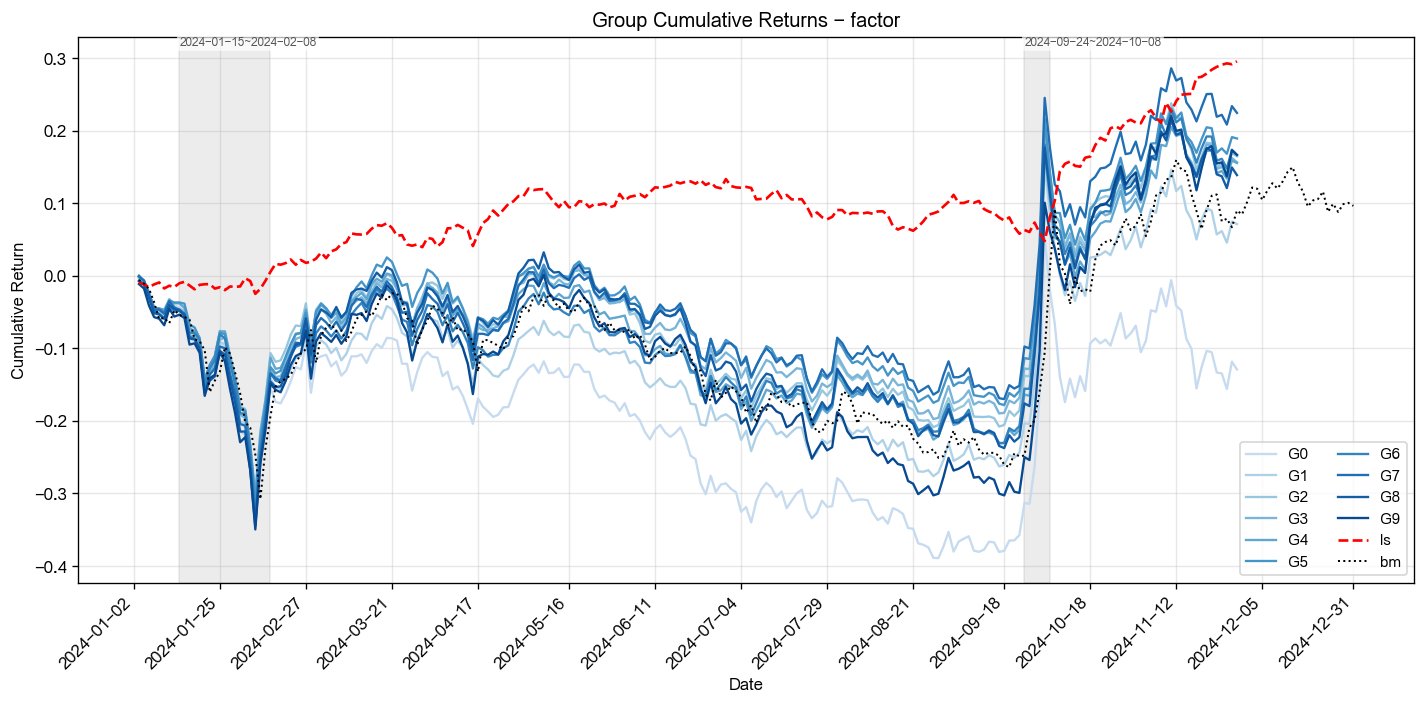
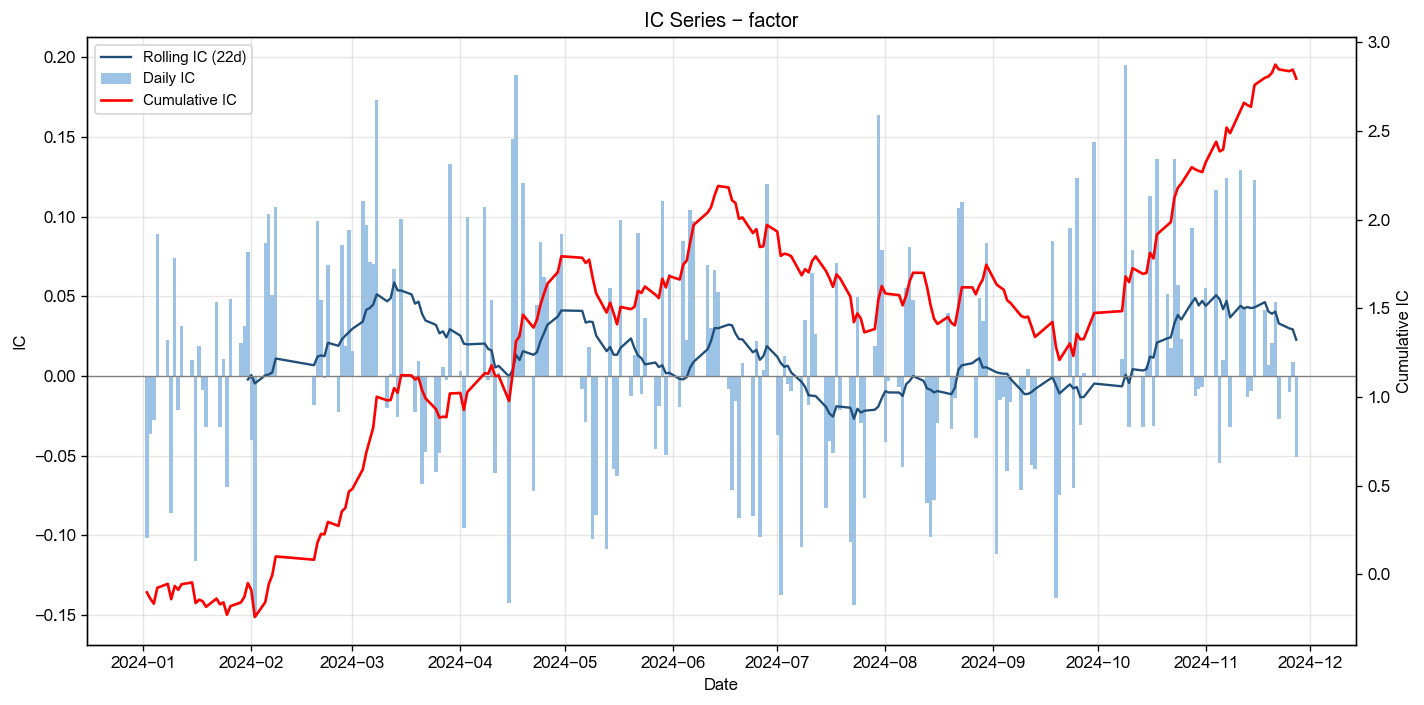
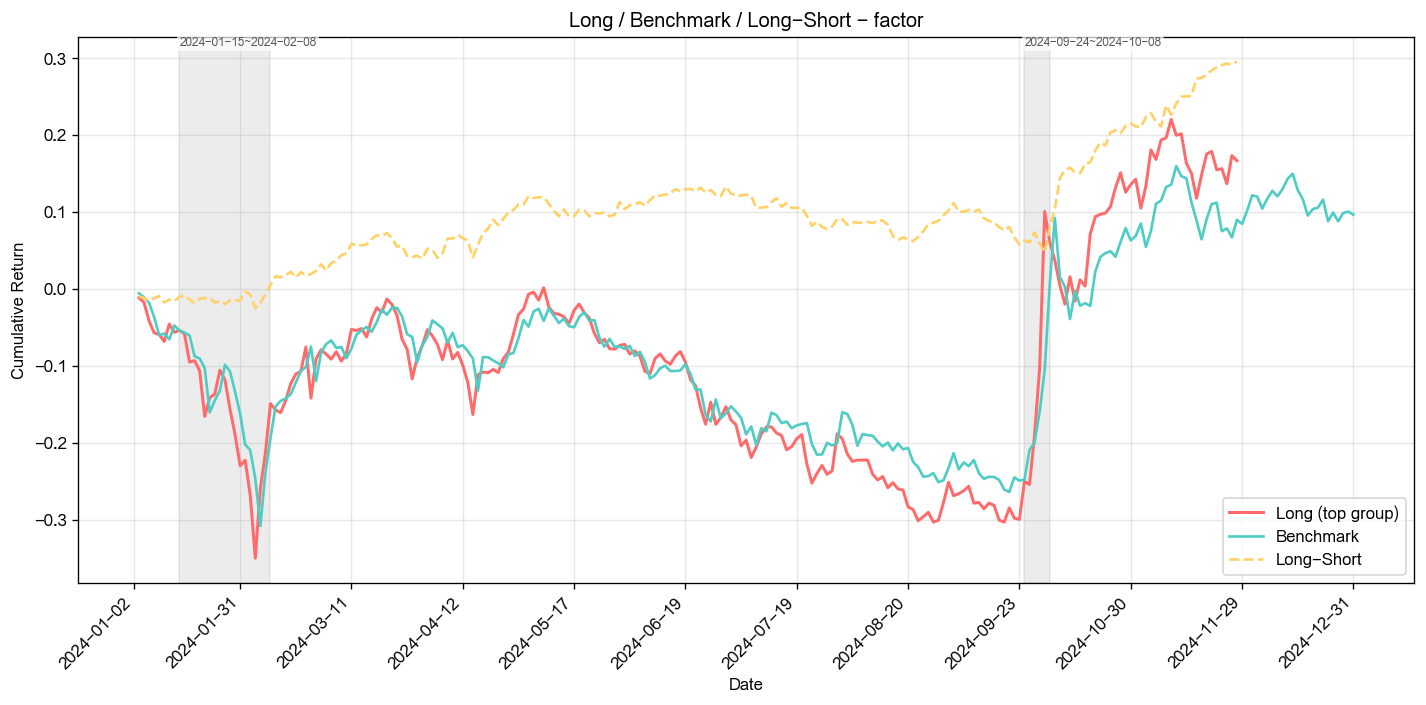
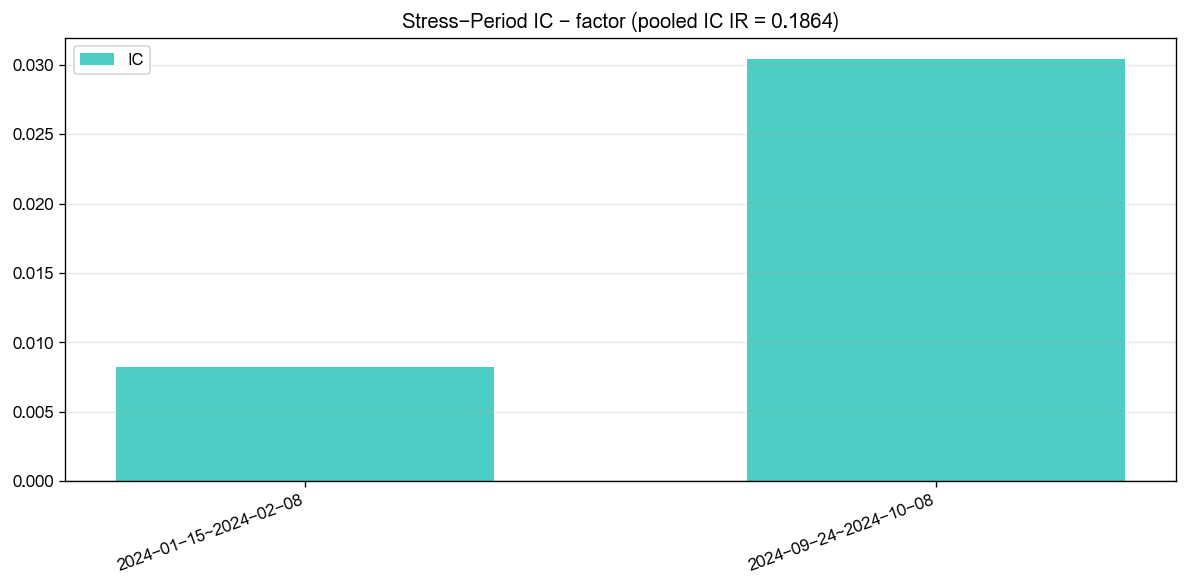
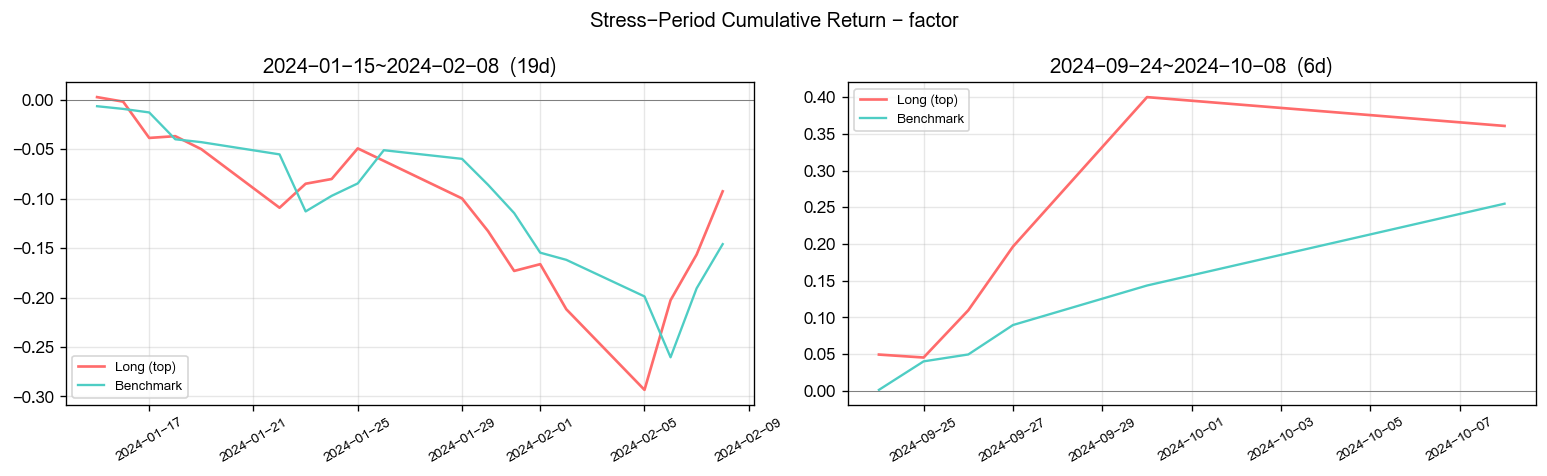

[2026-08-01 16:08:53] [info     ] ========== 因子池回归 ==========
[2026-08-01 16:08:53] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-01 16:08:54] [info     ] 获取收益率数据, 耗时: 0.6209 秒
[2026-08-01 16:08:54] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.1448 秒
[2026-08-01 16:08:54] [info     ] 统计 回归结果, 耗时: 0.0846 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,2.0015,0.0437,0.0218,1.0000
2,amount,1.7543,0.0186,0.0106,1.0000
3,gross_profit_rate_ttm,1.5301,0.0068,0.0044,1.0000
4,netflow_amount_main,1.5224,0.0256,0.0168,1.0000
5,cci_14,1.4854,0.0353,0.0238,1.0000
6,net_profit_rate_ttm,1.4523,0.0039,0.0027,0.8000
7,bias_20,1.4516,0.0291,0.0201,0.9000
8,netflow_amount_rate_main,1.4454,0.0093,0.0065,1.0000
9,pb,1.4178,0.0096,0.0068,0.9000
10,macd_hist_12_26_9,1.3270,0.0064,0.0048,1.0000

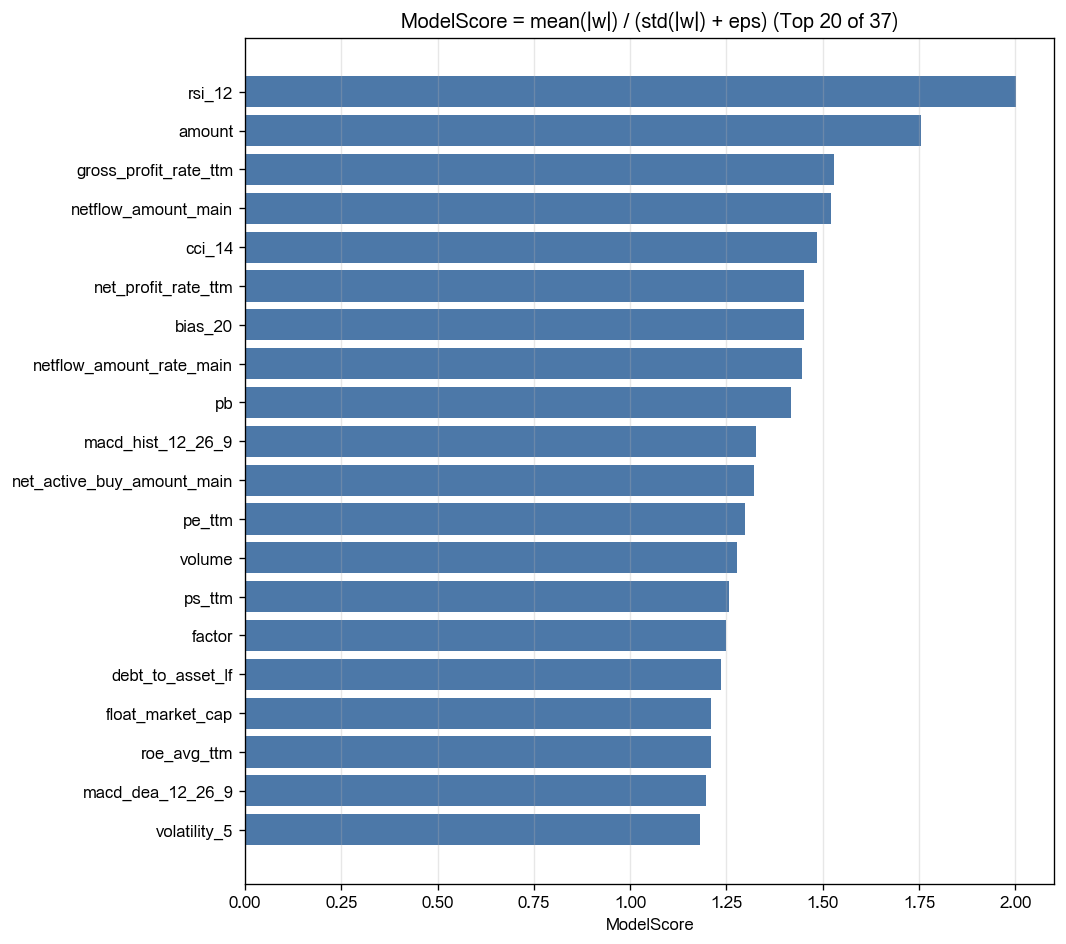
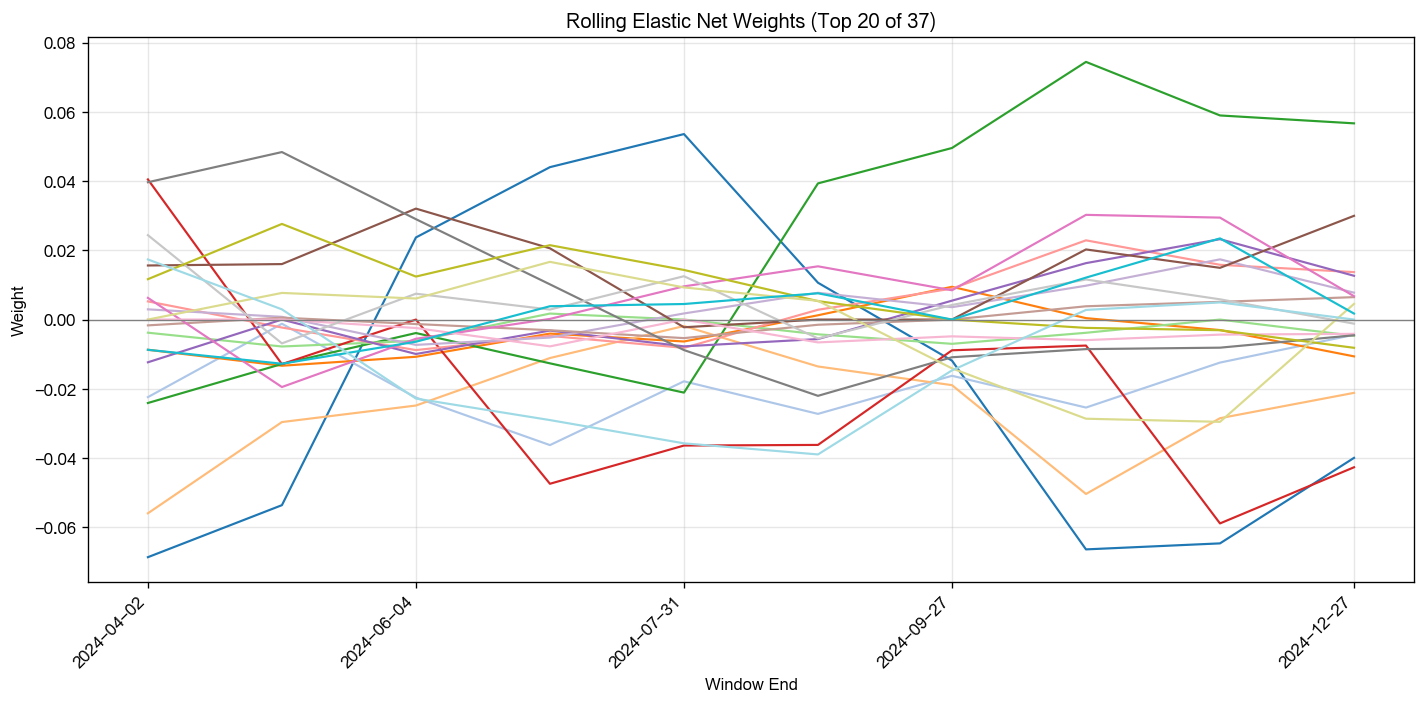
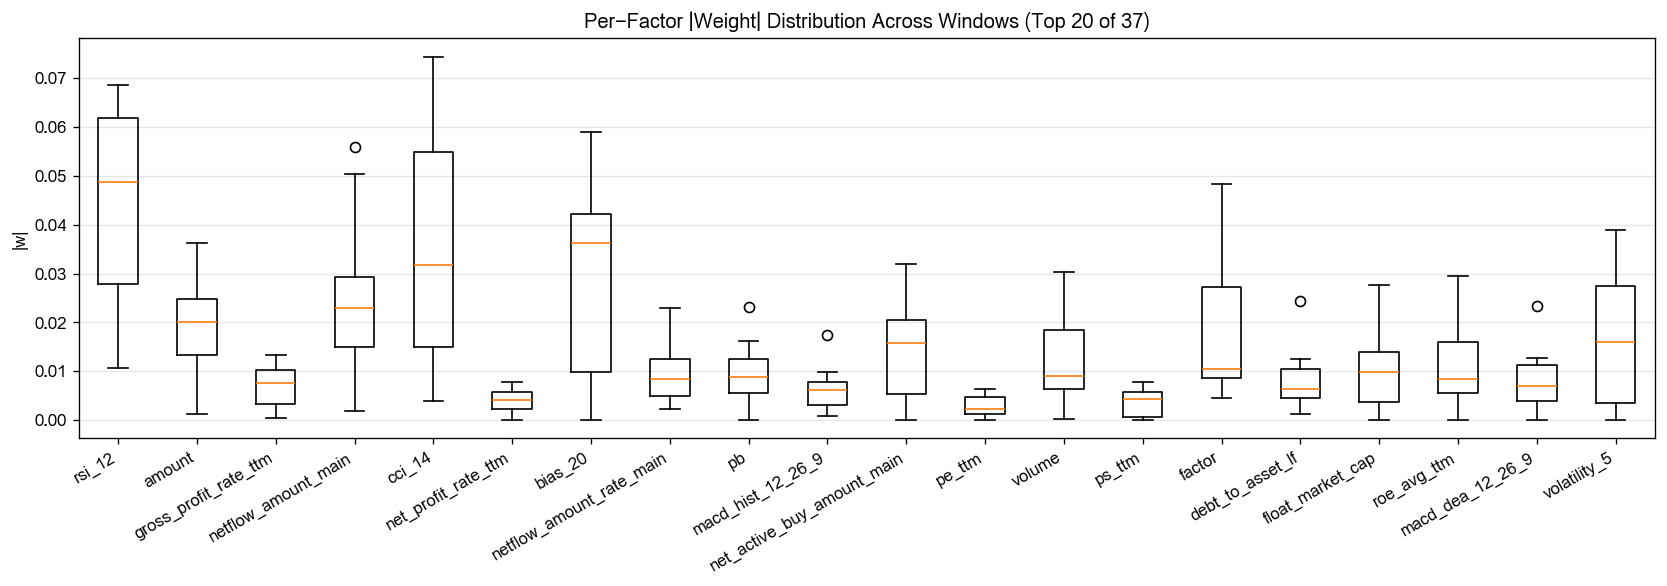
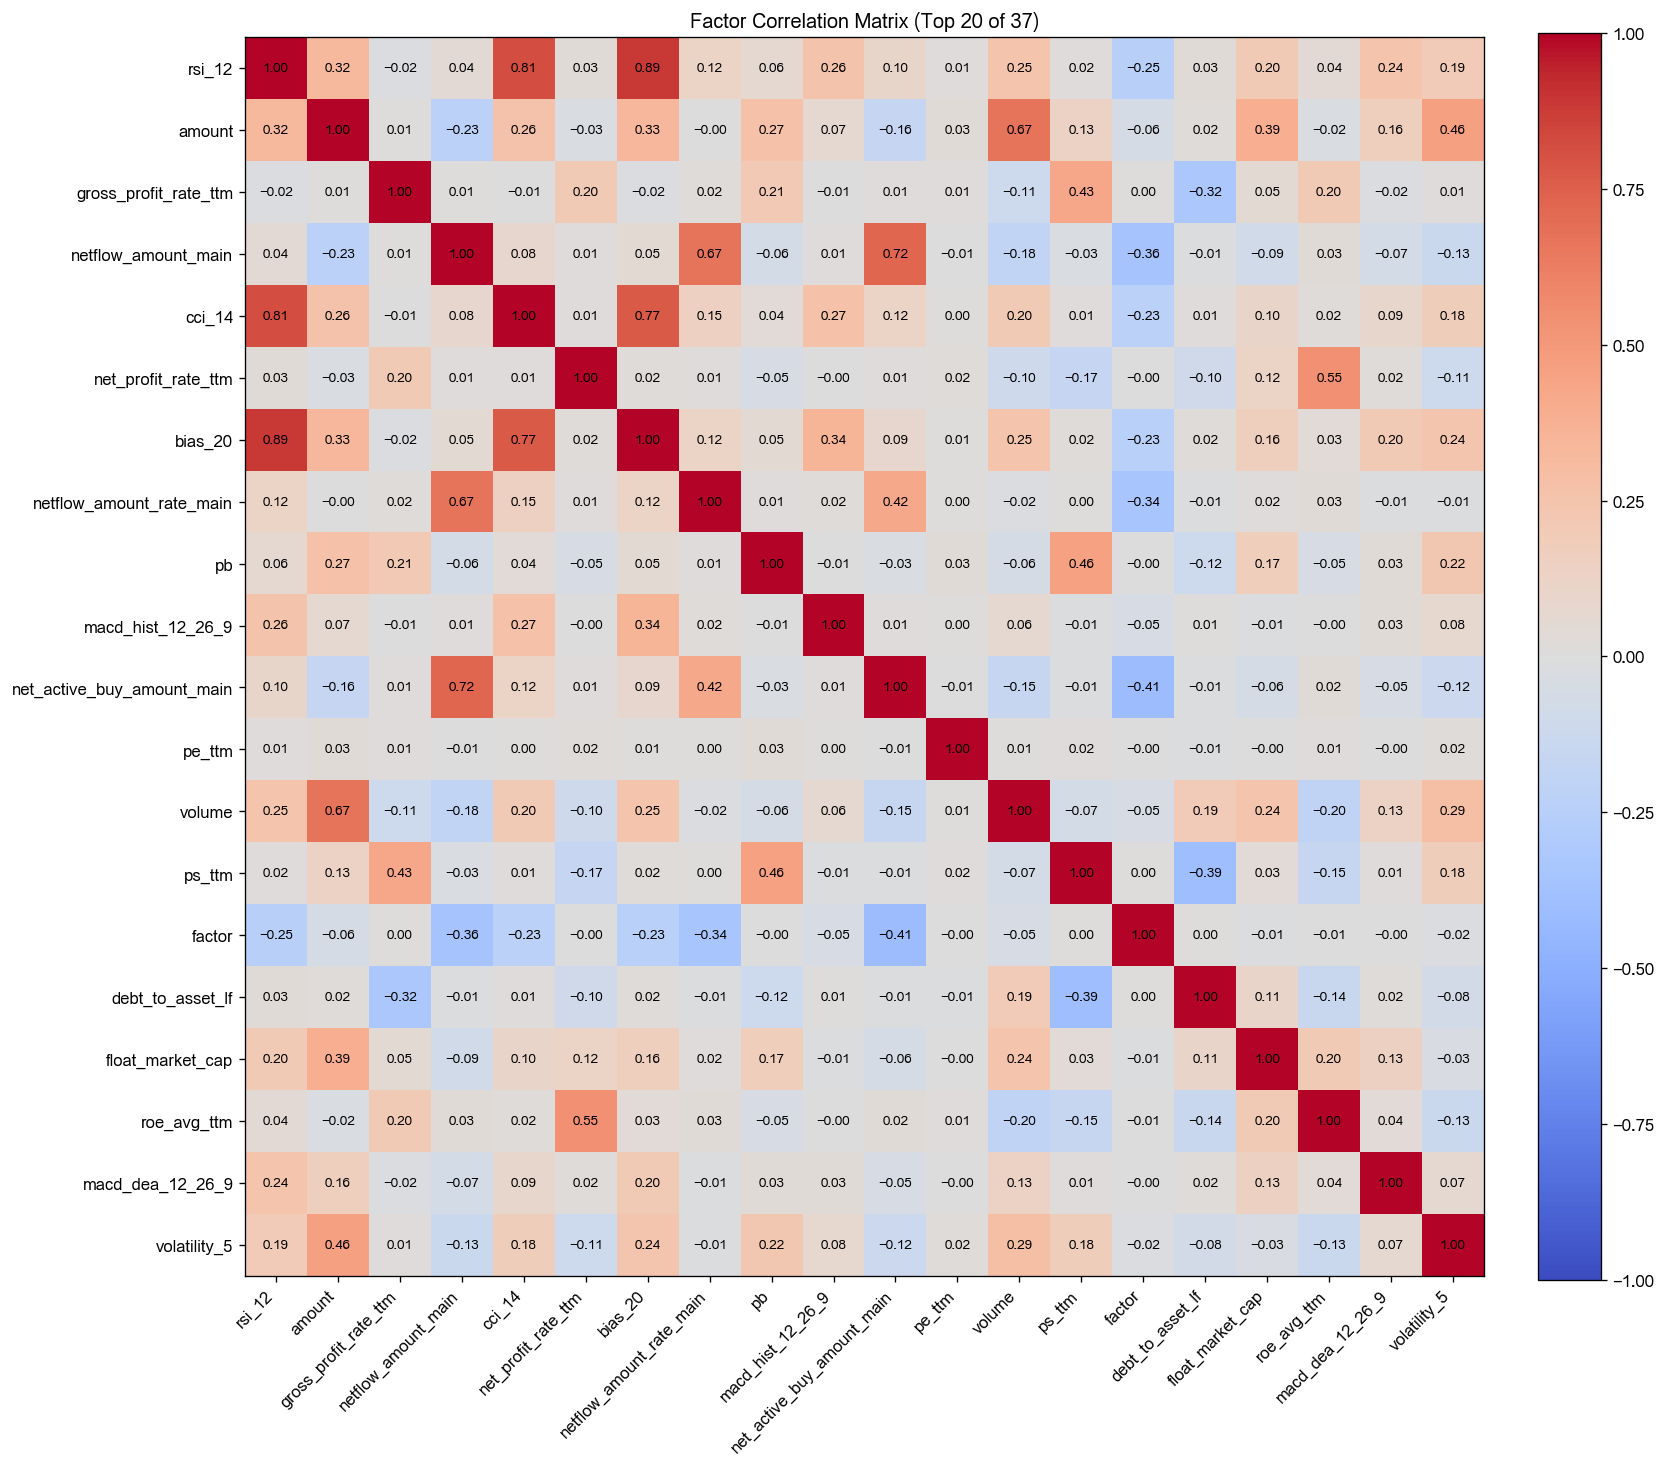

[2026-08-01 16:08:57] [warning  ] 返回的Outputs实例(size=126938816) 大于 64K, 将不会被缓存
[2026-08-01 16:08:57] [info     ] bigalpha_eval.v4 运行完成 [12.045s].

模型增量：
factor  model_score  abs_weight_mean  abs_weight_std  selection_rate
factor     1.249606         0.019009        0.015212             1.0


In [7]:
from bigmodule import M
import dai
import pandas as pd

start_date = "2024-01-01 00:00:00"
end_date = "2024-12-31 23:59:59"

# ============================================================
# 1. 读取官方基础因子池
# ============================================================
factor_pool = dai.query(
    """
    SELECT *
    FROM bigalpha_2026_factorlib
    """,
    filters={
        "date": [
            start_date,
            end_date
        ]
    },
    compression=True
).df()

factor_pool["date"] = pd.to_datetime(
    factor_pool["date"],
    errors="coerce"
).dt.normalize()

factor_pool["instrument"] = (
    factor_pool["instrument"]
    .astype(str)
    .str.strip()
)

factor_pool = (
    factor_pool
    .dropna(
        subset=[
            "date",
            "instrument"
        ]
    )
    .drop_duplicates(
        subset=[
            "date",
            "instrument"
        ],
        keep="last"
    )
)

print("新因子形状：", factor_data.shape)
print("官方因子池形状：", factor_pool.shape)

# ============================================================
# 2. 官方本地评估
# ============================================================
evaluation_result = M.bigalpha_eval._latest(
    factor_data=factor_data,
    factor_pool=factor_pool,
    start_date=start_date,
    end_date=end_date,
    process_pools=False,
    show=True
)

# ============================================================
# 3. 安全读取评估结果
# ============================================================
if isinstance(evaluation_result, dict):
    regression = evaluation_result.get(
        "factor_regression",
        {}
    )
else:
    regression = getattr(
        evaluation_result,
        "factor_regression",
        {}
    )

if isinstance(regression, dict):
    scores = regression.get(
        "per_factor_scores"
    )
else:
    scores = getattr(
        regression,
        "per_factor_scores",
        None
    )

if scores is not None and len(scores) > 0:
    print("\n模型增量：")
    print(
        scores[
            scores["factor"] == "factor"
        ].to_string(index=False)
    )
else:
    print(
        "\n未能从返回对象中读取模型增量，"
        "请以上方官方评估日志为准。"
    )

新因子形状： (1456000, 3)
官方因子池形状： (1456000, 38)
[2026-08-01 16:08:58] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-01 16:09:13] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-01 16:09:15] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2019-01-02 至 2024-12-31
[2026-08-01 16:09:15] [info     ] ========== 数据检查 ==========
[2026-08-01 16:09:15] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_active_buy_amount_main', 'beta_000300SH_22', '

时段,IC
2020-02-03~2020-03-31,-0.0175
2024-01-15~2024-02-08,0.0082
2024-09-24~2024-10-08,0.0304

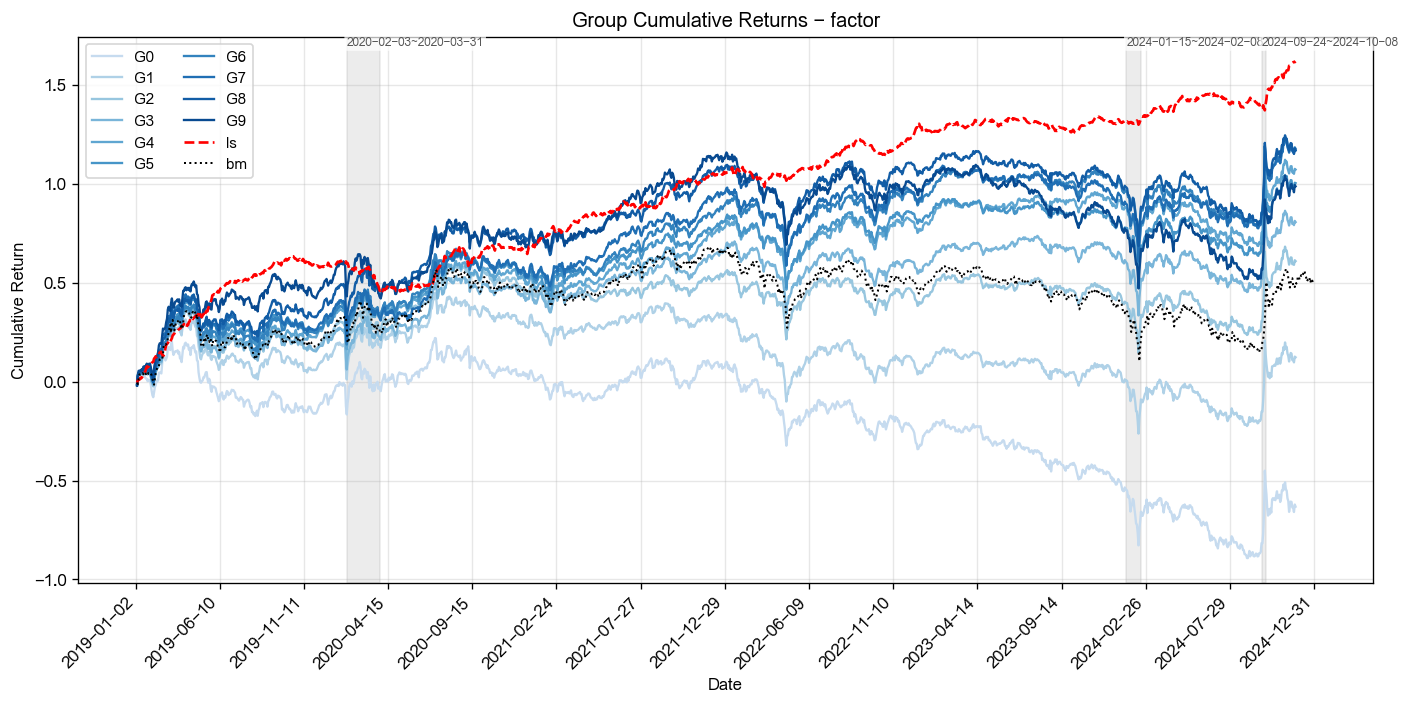
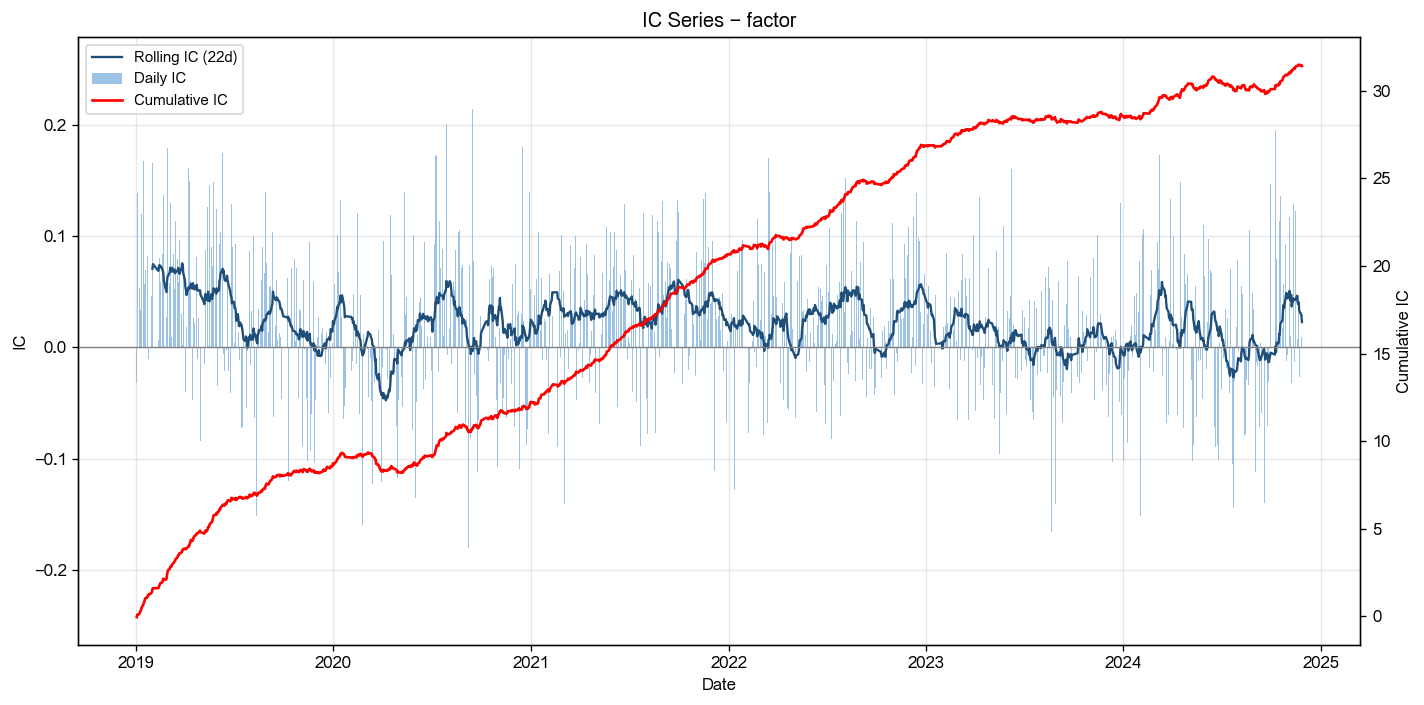
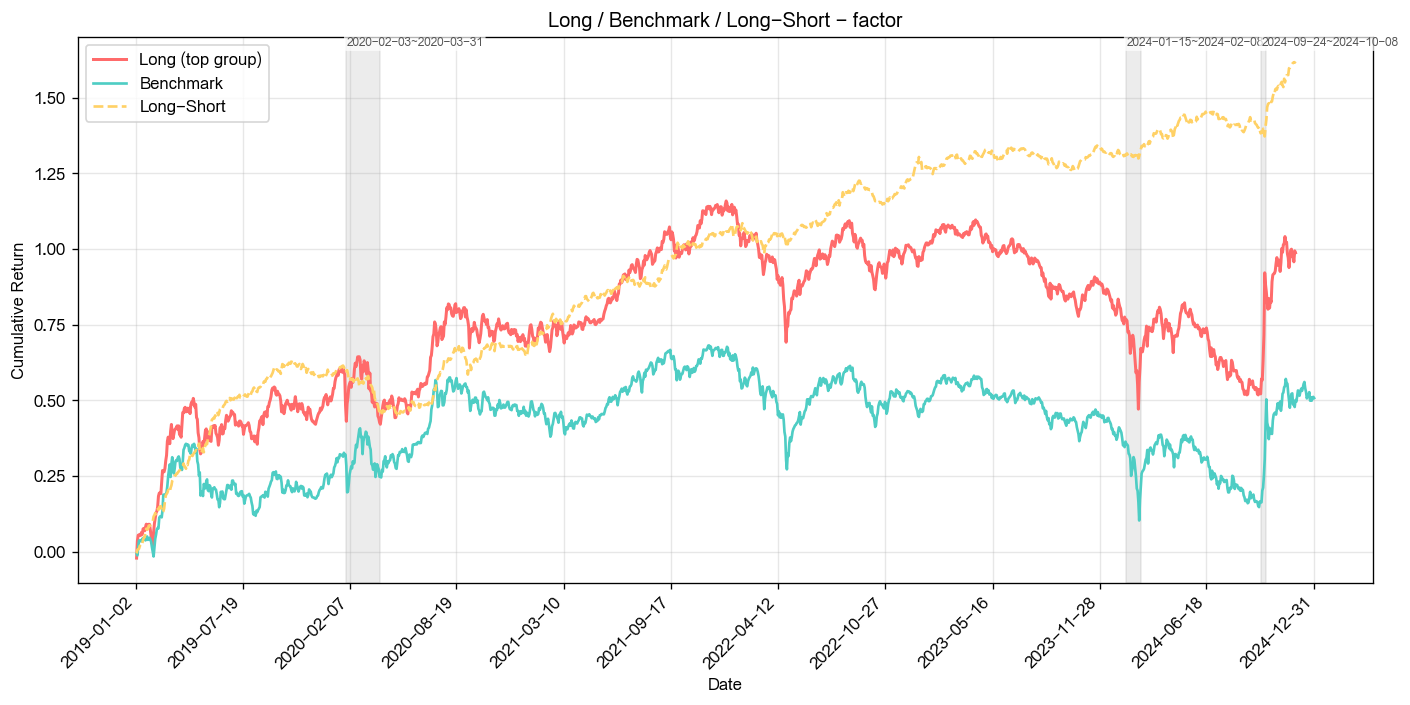
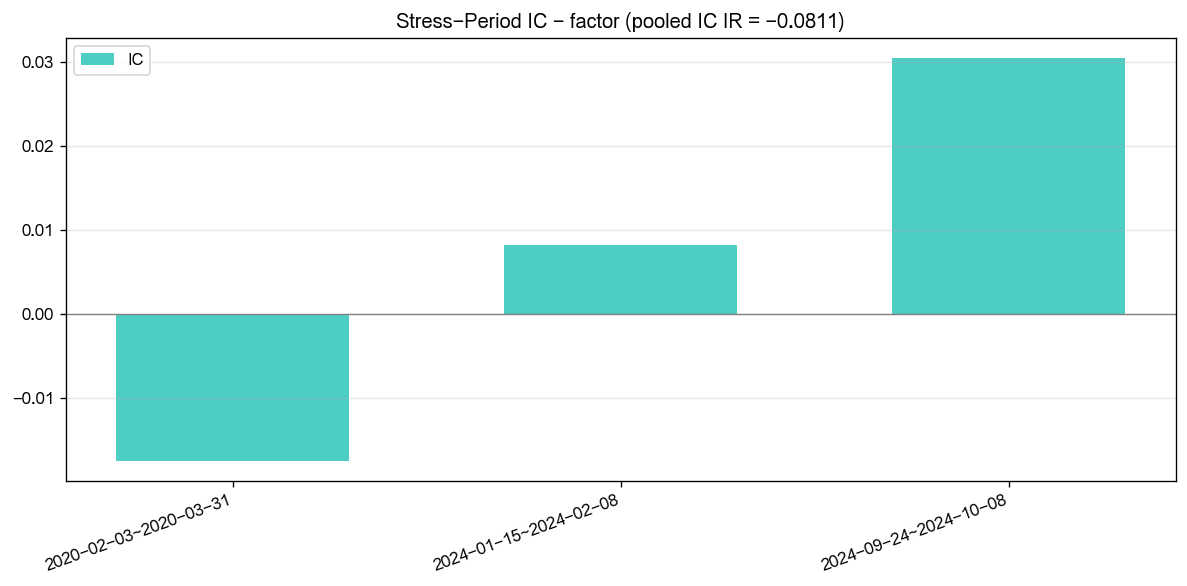
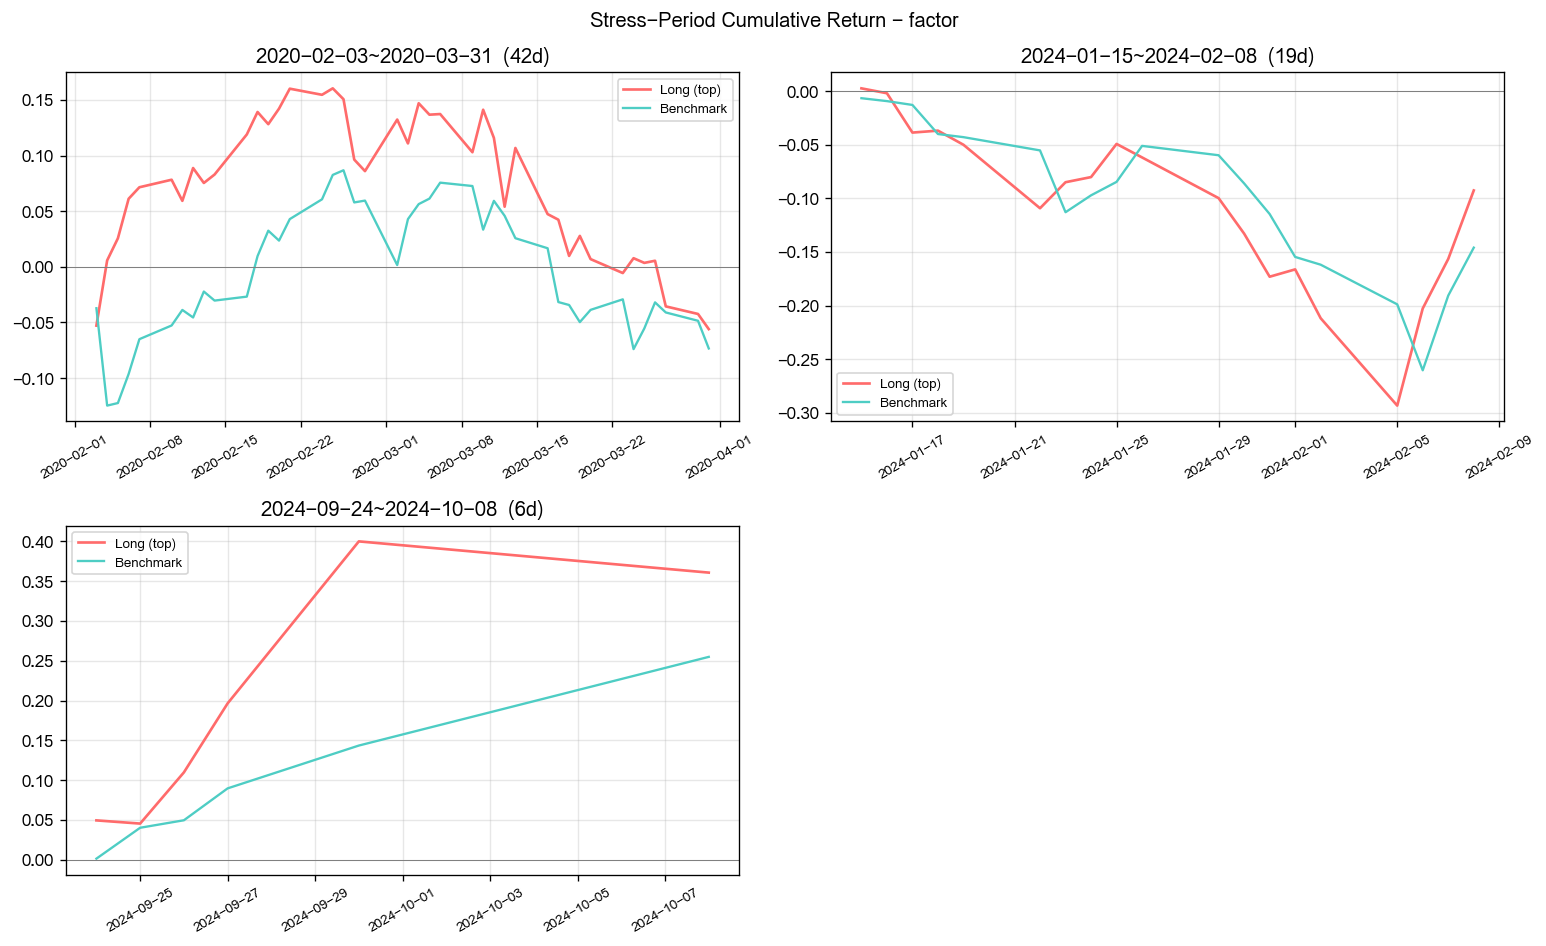

[2026-08-01 16:09:58] [info     ] ========== 因子池回归 ==========
[2026-08-01 16:10:00] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=2075 rows=2695583 start_date=2019-01-02
[2026-08-01 16:10:02] [info     ] 获取收益率数据, 耗时: 3.9206 秒
[2026-08-01 16:10:03] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.8764 秒
[2026-08-01 16:10:03] [info     ] 统计 回归结果, 耗时: 0.0106 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,beta_000300SH_22,1.5432,0.0176,0.0114,0.9857
2,turn,1.4691,0.0262,0.0179,0.9429
3,bias_20,1.4093,0.0299,0.0212,0.9571
4,cci_14,1.3905,0.0283,0.0203,0.9714
5,list_days,1.3550,0.0104,0.0077,0.9429
6,momentum_5,1.3520,0.0176,0.0130,0.9571
7,factor,1.3305,0.0197,0.0148,0.9714
8,net_active_buy_amount_main,1.3275,0.0171,0.0129,0.9143
9,reversal_5,1.2748,0.0093,0.0073,0.9571
10,net_profit_rate_ttm,1.2714,0.0066,0.0052,0.9429

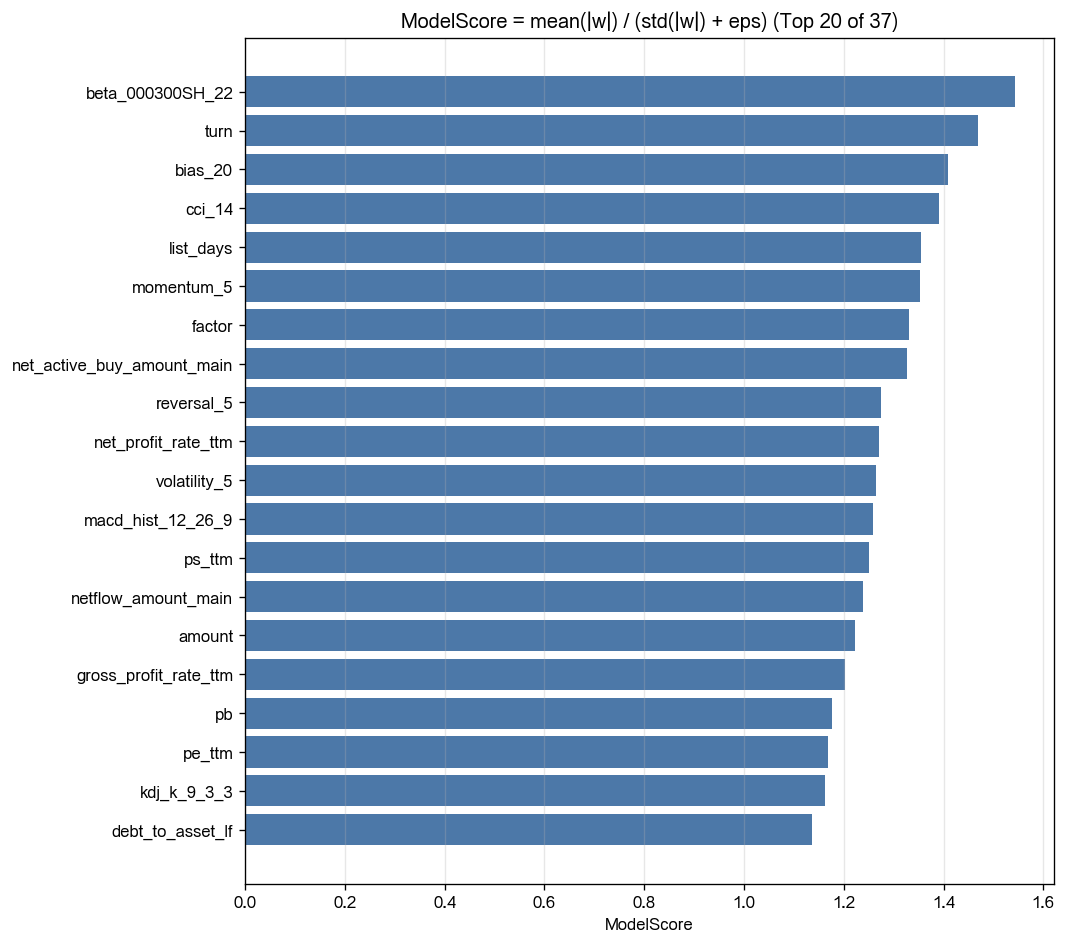
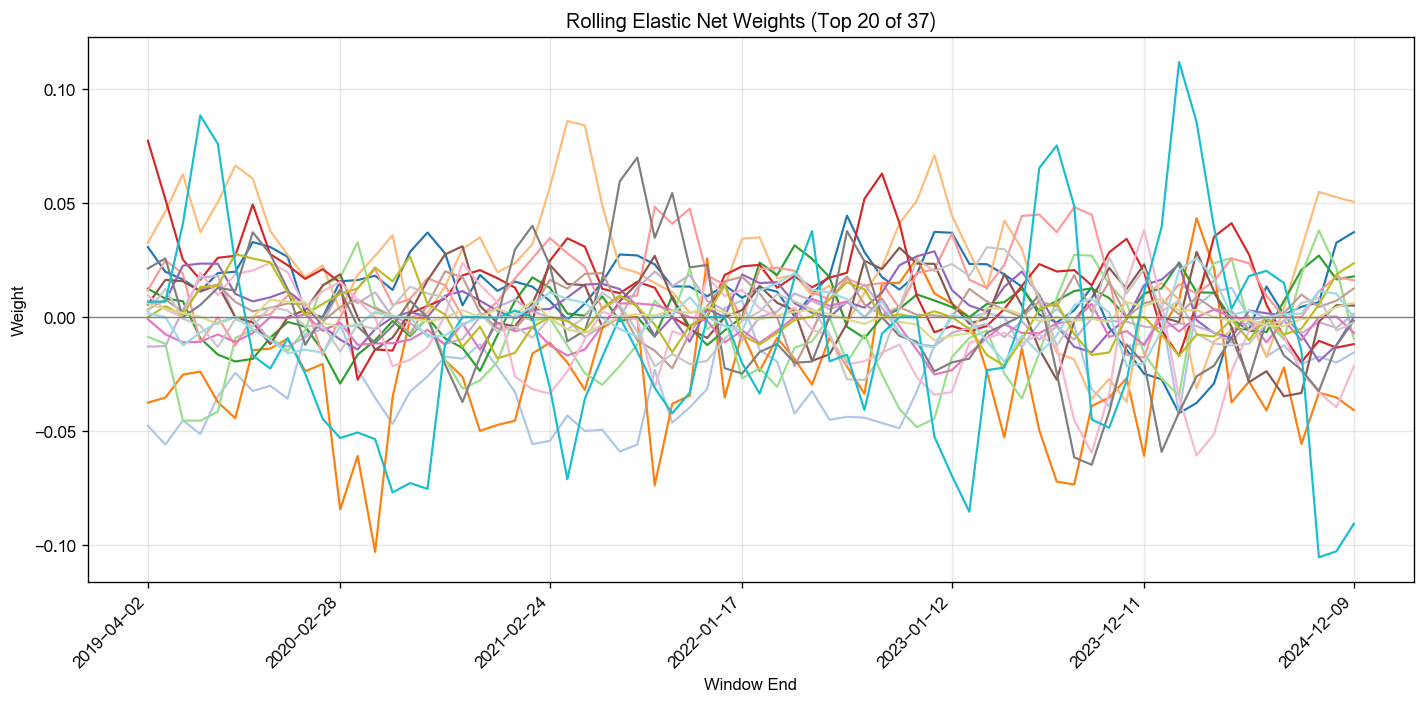
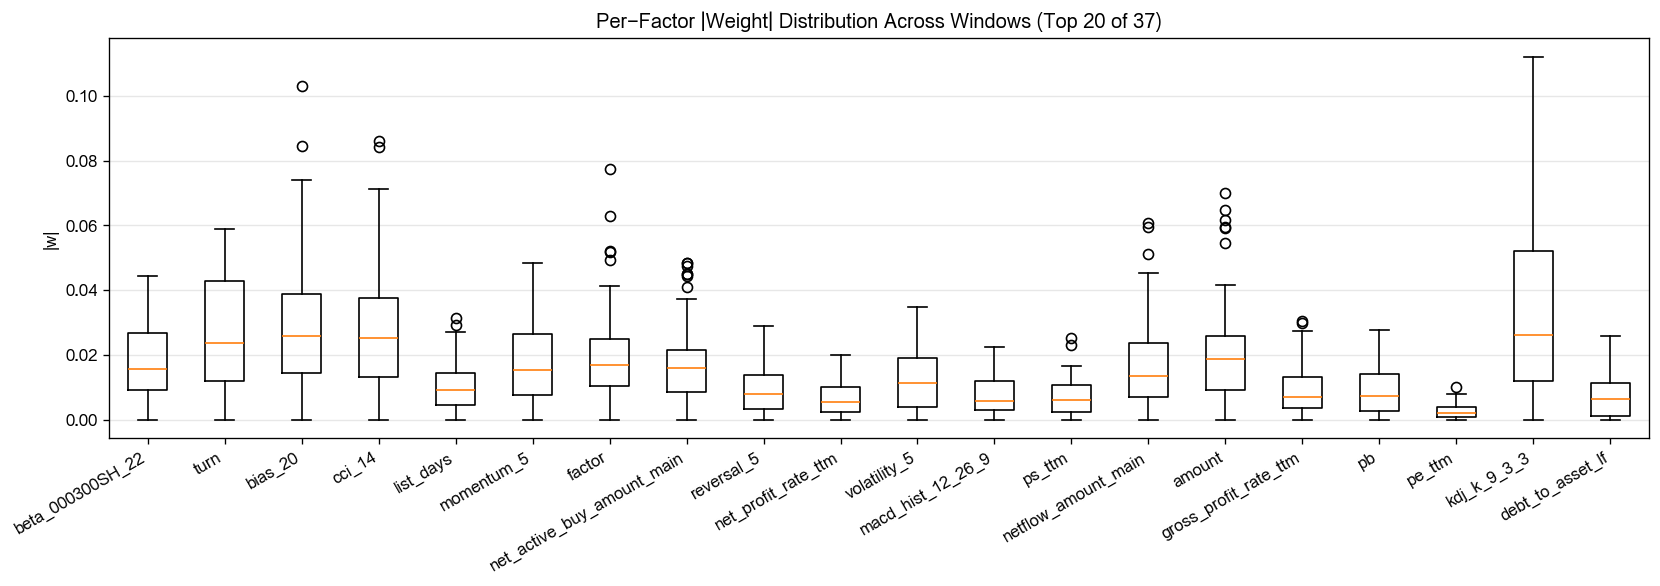
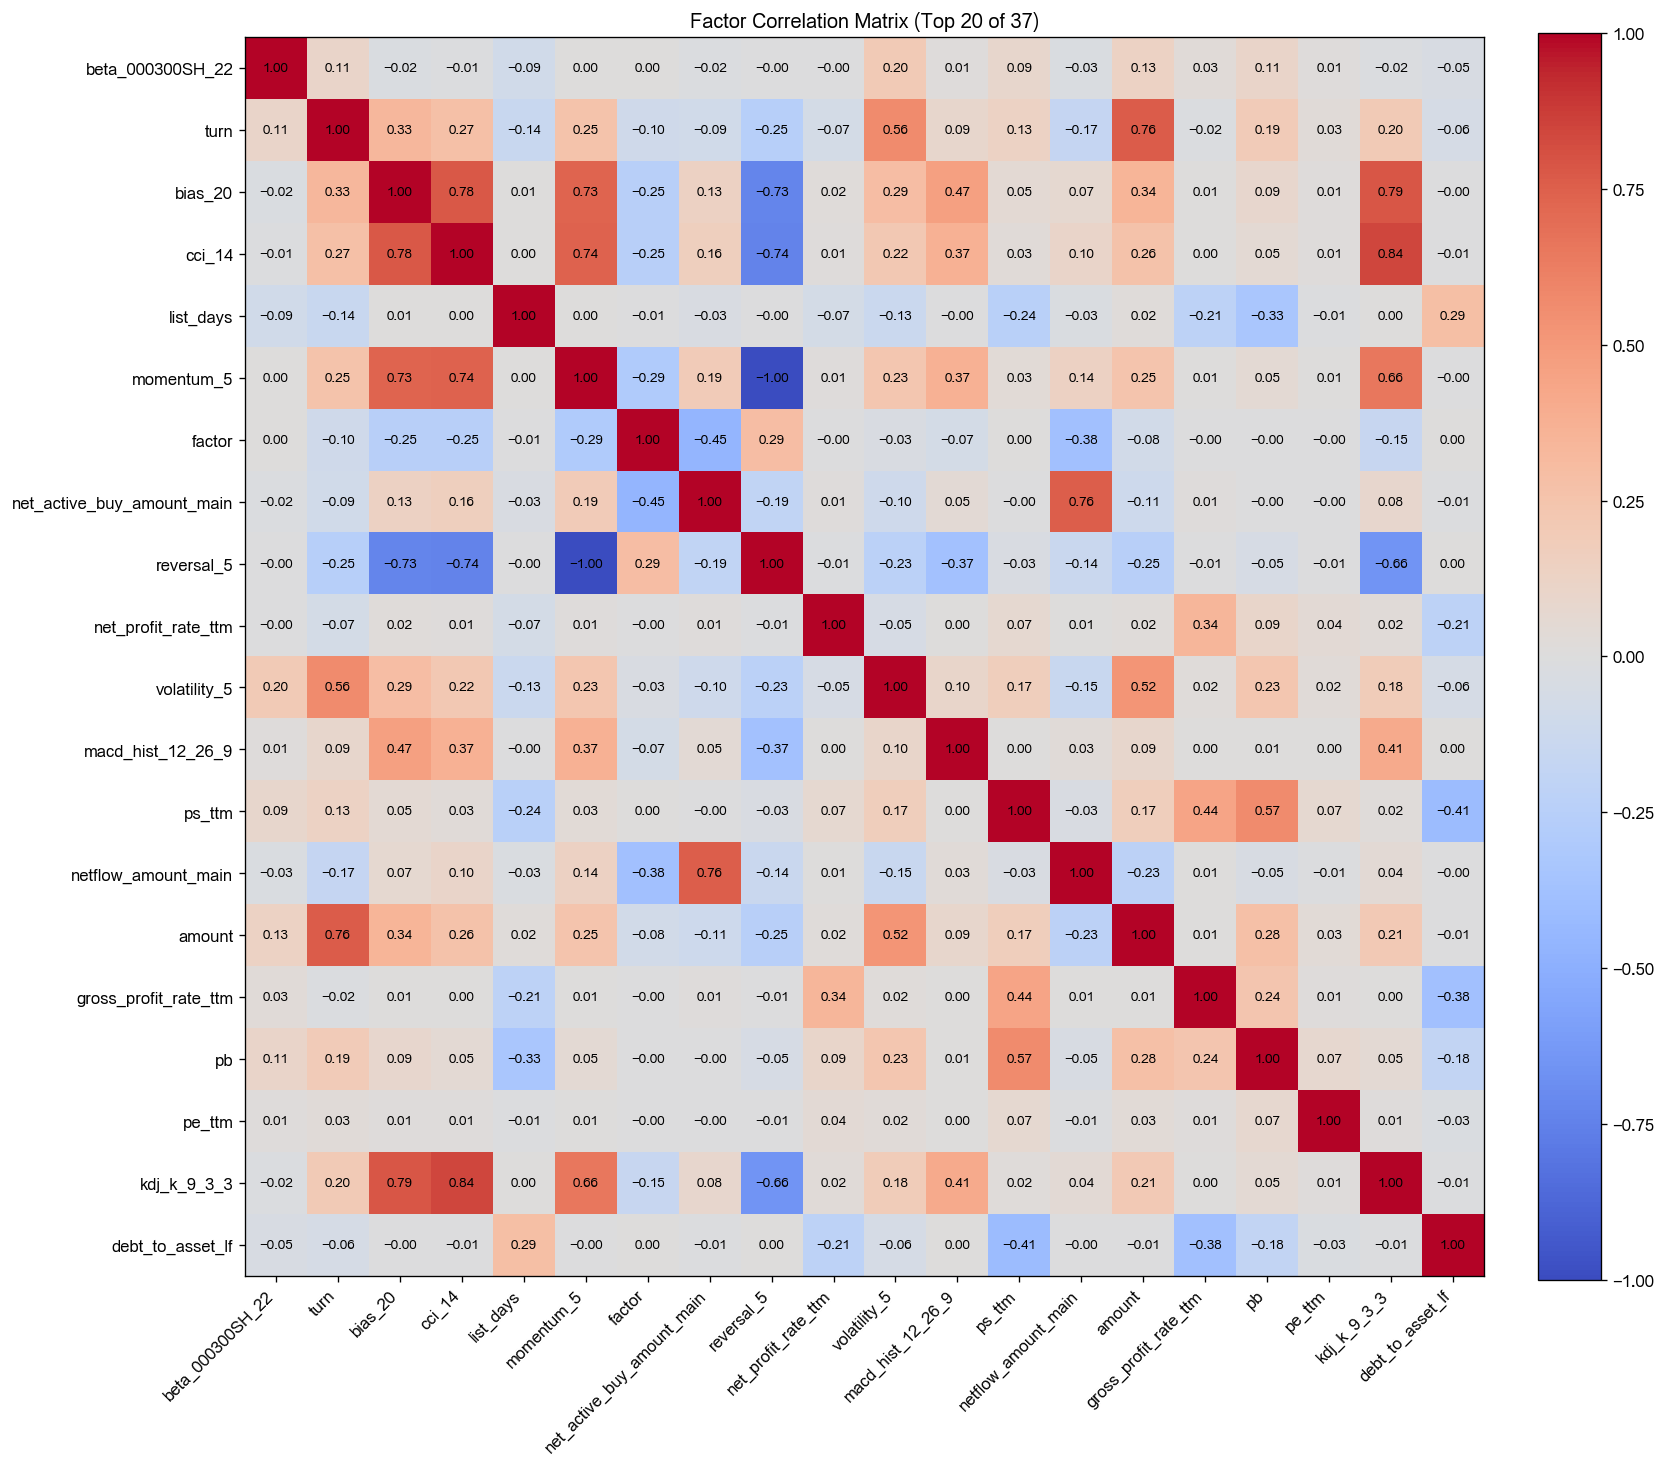

[2026-08-01 16:10:08] [warning  ] 返回的Outputs实例(size=218614203) 大于 64K, 将不会被缓存
[2026-08-01 16:10:08] [info     ] bigalpha_eval.v4 运行完成 [55.170s].

模型增量：
factor  model_score  abs_weight_mean  abs_weight_std  selection_rate
factor     1.330546         0.019651        0.014769        0.971429


In [8]:
from bigmodule import M
import dai
import pandas as pd

start_date = "2019-01-01 00:00:00"
end_date = "2024-12-31 23:59:59"

# ============================================================
# 1. 读取官方基础因子池
# ============================================================
factor_pool = dai.query(
    """
    SELECT *
    FROM bigalpha_2026_factorlib
    """,
    filters={
        "date": [
            start_date,
            end_date
        ]
    },
    compression=True
).df()

factor_pool["date"] = pd.to_datetime(
    factor_pool["date"],
    errors="coerce"
).dt.normalize()

factor_pool["instrument"] = (
    factor_pool["instrument"]
    .astype(str)
    .str.strip()
)

factor_pool = (
    factor_pool
    .dropna(
        subset=[
            "date",
            "instrument"
        ]
    )
    .drop_duplicates(
        subset=[
            "date",
            "instrument"
        ],
        keep="last"
    )
)

print("新因子形状：", factor_data.shape)
print("官方因子池形状：", factor_pool.shape)

# ============================================================
# 2. 官方本地评估
# ============================================================
evaluation_result = M.bigalpha_eval._latest(
    factor_data=factor_data,
    factor_pool=factor_pool,
    start_date=start_date,
    end_date=end_date,
    process_pools=False,
    show=True
)

# ============================================================
# 3. 安全读取评估结果
# ============================================================
if isinstance(evaluation_result, dict):
    regression = evaluation_result.get(
        "factor_regression",
        {}
    )
else:
    regression = getattr(
        evaluation_result,
        "factor_regression",
        {}
    )

if isinstance(regression, dict):
    scores = regression.get(
        "per_factor_scores"
    )
else:
    scores = getattr(
        regression,
        "per_factor_scores",
        None
    )

if scores is not None and len(scores) > 0:
    print("\n模型增量：")
    print(
        scores[
            scores["factor"] == "factor"
        ].to_string(index=False)
    )
else:
    print(
        "\n未能从返回对象中读取模型增量，"
        "请以上方官方评估日志为准。"
    )